# PIA - Video Con Descubrimientos
    Usando las herramientas y algoritmos proporcionados a lo largo de todas las practicas, intentaremos contestar preguntas interesantes acerca de nuestro dataset, para finalizar realizaremos un video contando nuestros descubrimientos. 

    Hay varias preguntas que me gustaria contestar:
    - El mercado japones le es fiel a sus consolas (nintendo y sony) o tambien suelen comprar productos de extrangeros (Xbox)?
    - Cada vez se hacen mas juegos de deportes?
    - Que mercado es el que mas aporta al genero de Shooter? 
    - Cual es el genero que difiere de los otros en cuanto a ventas globales? (uso de las pruebas de hipotesis de la practica 4)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
import scikit_posthocs as sp

data = pd.read_csv("../datasets/vgsales_clean.csv")
data.head()

,Nombre,Plataforma,Año,Género,Publicador,Ventas_Norteamérica,Ventas_Europa,Ventas_Japón,Ventas_Otros,Ventas_Globales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### 1 - El mercado japones le es fiel a nintendo y sony (a sus propias empresas) o tambien suelen comprar productos extrangeros (xbox)?

    Esta es una pregunta relativamente sencilla de responder, ya que se contesta con estadistica descriptiva basica

Fabricante
Microsoft    0.011558
Nintendo     0.132299
Sony         0.085583
Name: Ventas_Japón, dtype: float64


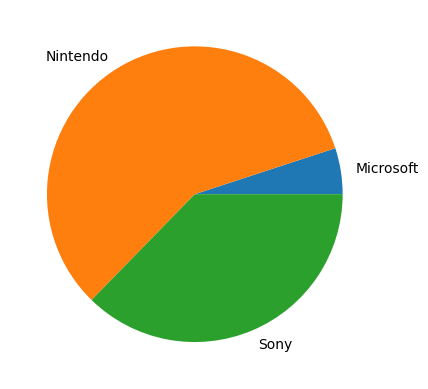

In [4]:
#En este codigo se realiza una agregacion entre algunas consolas japonesas y su competencia que es microsoft
filtro = ['Wii','NES','DS','X360','PS3','PS2','3DS','PS4','N64','PS','XB','PSP','WiiU','XOne']
data_prueba1 = data[data["Plataforma"].isin(filtro)].copy()
data_prueba1['Fabricante'] = data_prueba1['Plataforma'].apply(
    lambda x: 'Nintendo' if x in ['Wii','NES','DS','3DS','N64','WiiU']
    else 'Microsoft' if x in ['X360','XB','XOne']
    else 'Sony' if x in ['PS','PS2','PS3','PS4','PSP']
    else 'Otro'
)
pastel1 = data_prueba1.groupby(['Fabricante'])['Ventas_Japón'].mean()
print(pastel1)
fig, ax = plt.subplots()
ax.pie(pastel1.values, labels=pastel1.index)
plt.show()

    Conclusion 1: Podemos apreciar por la distribucion de la media en cada uno de los fabricantes que existe una clara preferencia en japon hacia productos de Nintento y Sony, dejando a Microsoft una empresa extrangera relegada. 

### 2 - Cada vez se hacen mas juegos de deportes?
    Para contestar esta pregunta es necesario crear una regresion lineal simple usando el tiempo como variable independendiente y la cantidad de juegos deportivos por anio como dependendiente. Una vez hecho esto analizaremos el valor de la pendiente que nos indicara si existe una tendencia a la baja o a la alta. 
    

R² Score: 0.8576   ---   El modelo predice con exito la variable dependiente



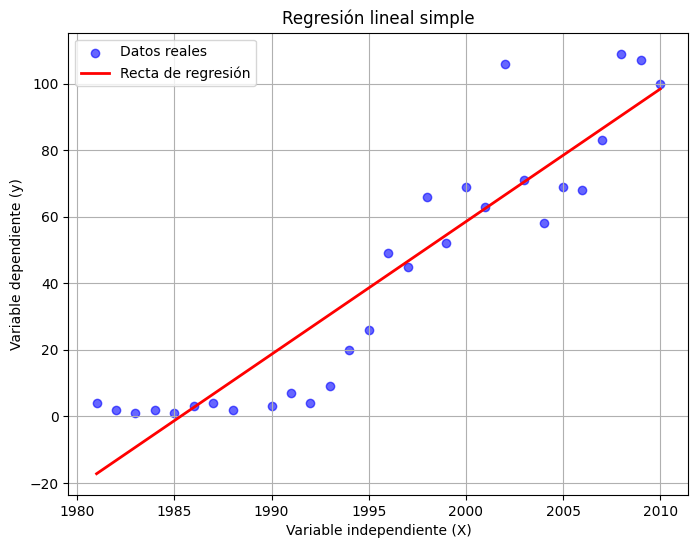

Pendiente: 3.9867
Intersección (ordenada al origen): -7914.8708


In [5]:
data_prueba2 = data[data['Género'] == 'Sports'].copy()
conteo = data_prueba2['Año'].value_counts().sort_index()
conteo = conteo.loc[1981:2010]
def modelo_lineal_simple(X, y):
    """Imprime un grafico de la regresion lineal junto a los datos originales, aparte de 
    retornar el modelo de regresion"""
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)
    # Crear y entrenar el modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    # Predicciones
    y_pred = modelo.predict(X)
    # Calcular R²
    r2 = r2_score(y, y_pred)
    if r2 > 0.80:
        print(f"R² Score: {r2:.4f}   ---   El modelo predice con exito la variable dependiente", end="\n\n")
    else:
        print(f"R² Score: {r2:.4f}   ---   El modelo no predice con exito la variable dependiente", end="\n\n") 
    # Graficar la recta de regresión junto con los datos originales
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', label='Datos reales', alpha=0.6)
    plt.plot(X, y_pred, color='red', linewidth=2, label='Recta de regresión')
    plt.xlabel('Variable independiente (X)')
    plt.ylabel('Variable dependiente (y)')
    plt.title('Regresión lineal simple')
    plt.legend()
    plt.grid(True)
    plt.show()
    return modelo

    
X = conteo.index  #Tiempo
y = conteo.values # Cantidad de juegos
#uso del modelo
modelo = modelo_lineal_simple(X, y)

pendiente = modelo.coef_[0]
interseccion = modelo.intercept_

print(f"Pendiente: {pendiente:.4f}")
print(f"Intersección (ordenada al origen): {interseccion:.4f}")



    CONCLUSION 2: Podemos ver que el genero de deportes tiende a la alta con una pendiente aproximandose casi a 4, por lo que podemos concluir que en el transcurso del tiempo de 1980 al 2010 cada vez fueron saliendo mas juegos de deportes.     

### 3 - Que mercado es el que mas aporta al genero de Shooter?
    Esta pregunta es similar a la primera ya que se contesta facilmente con algebra descriptiva, procederemos a hacer una filtracion de juegos de shooter para despues calcular la suma de de ventas de cada mercado. 
        

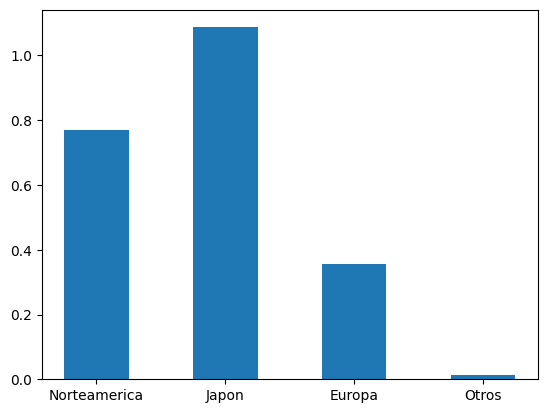

In [6]:
data_prueba3 = data[data['Género'] == 'Shooter'].copy()
poblaciones = {
    'Norteamerica': 592,
    'Japon':  112,
    'Europa': 744,
    'Otros': 6706
}

suma_mercados = data_prueba2[['Ventas_Norteamérica', 'Ventas_Japón', 'Ventas_Europa', 'Ventas_Otros']].sum().sort_values()

proporciones = {
    'Norteamerica': suma_mercados['Ventas_Norteamérica']/poblaciones['Norteamerica'],
    'Japon': suma_mercados['Ventas_Japón']/poblaciones['Japon'],
    'Europa': suma_mercados['Ventas_Europa']/poblaciones['Europa'],
    'Otros': suma_mercados['Ventas_Otros']/poblaciones['Otros']
}

plt.bar(proporciones.keys(),proporciones.values(), width = 0.5)
plt.show()

    Conclusion: AL final encontramos la proporcion por habitante y obtuvimos que japon es de los que mas aporta al genero del shooter por habitante, esto en verdad me sorprendio ya que existe cierto prejuicio acerca que los juegos violentos generan violencia. Sin embargo, Japon es uno de los paises mas seguros del mundo y es uno de los que mas consume este tipo de genero por habitante. 
    Esta conclusion solo esta sujeta a estos datos en especifico y a la distribucion que poseen. 

### Cual es el genero que difiere de los otros en cuanto a ventas globales? (uso de las pruebas de hipotesis de la practica 4)

    Este pregunta es una continuacion de la practica 4 en donde comprobamos que existe un genero en el dataset que difiere de los demas en cuanto a ventas globales. Intentaremos encontrar cual o cuales son los generos que se distinguen de los demas usando 

C:\Users\Brayan\AppData\Local\Temp\ipykernel_12432\2457942963.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Género',


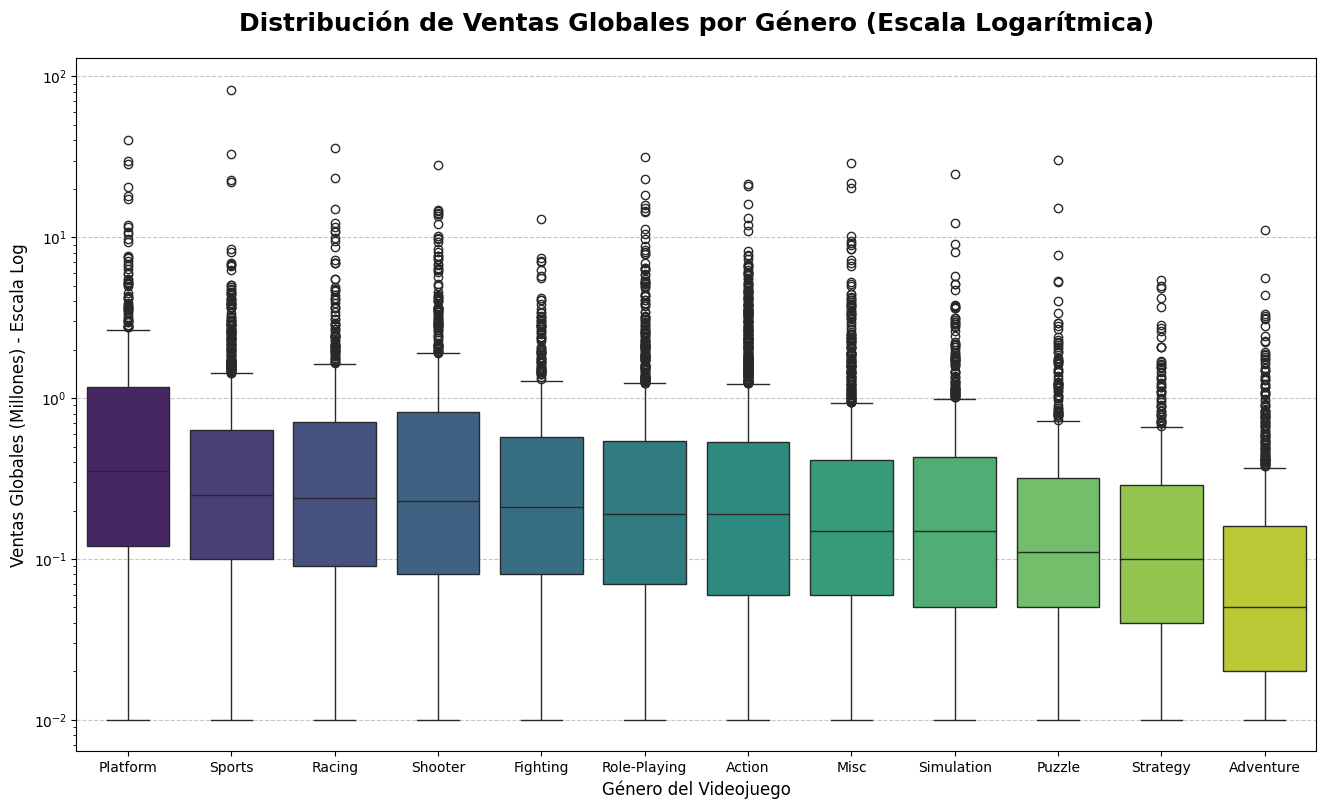

Género: Action               p-value: 4.00e-61    LOS DATOS NO SON NORMALES
Género: Adventure            p-value: 2.41e-52    LOS DATOS NO SON NORMALES
Género: Fighting             p-value: 8.50e-38    LOS DATOS NO SON NORMALES
Género: Misc                 p-value: 3.49e-57    LOS DATOS NO SON NORMALES
Género: Platform             p-value: 6.72e-41    LOS DATOS NO SON NORMALES
Género: Puzzle               p-value: 3.84e-41    LOS DATOS NO SON NORMALES
Género: Racing               p-value: 3.30e-46    LOS DATOS NO SON NORMALES
Género: Role-Playing         p-value: 9.97e-55    LOS DATOS NO SON NORMALES
Género: Shooter              p-value: 9.84e-45    LOS DATOS NO SON NORMALES
Género: Simulation           p-value: 2.91e-45    LOS DATOS NO SON NORMALES
Género: Sports               p-value: 4.32e-61    LOS DATOS NO SON NORMALES
Género: Strategy             p-value: 1.99e-38    LOS DATOS NO SON NORMALES
Estadístico H: 836.6730720086949
p-value: 2.52e-172    hay diferencias significativas en

In [10]:
# Codigo en funciones
def prueba_normalizacion(df):
    """Hace uso de la prueba Shapiro para comprobar la normalidad de los datos"""
    for genero, grupo in df.groupby("Género"):
        valores = grupo["Ventas_Globales"].values
        if len(valores) >= 3:  
            #Prueba shapiro
            stat, p_value = stats.shapiro(valores)
            if p_value < 0.05:
                print(f"Género: {genero:<20} p-value: {p_value:.2e}    LOS DATOS NO SON NORMALES")
            elif p_value >= 0.05:
                print(f"Género: {genero:<20} p-value: {p_value:.2e}    LOS DATOS SON NORMALES")

def prueba_grupos(df):
    """HAce uso de la prueba Kruskal-Wallis para comprobar la diferencias entre grupos"""
    grupos = [grupo["Ventas_Globales"].values 
          for nombre, grupo in df.groupby("Género")]

    # Kruskal-Wallis
    h_stat, p_value = stats.kruskal(*grupos)
    print("Estadístico H:", h_stat)
    if p_value < 0.05:
            print(f"p-value: {p_value:.2e}    hay diferencias significativas entre al menos un par de géneros")
    elif p_value >= 0.05:
            print(f"p-value: {p_value:.2e}    no hay evidencia suficiente para decir que los géneros difieran en ventas globales")
    return p_value


#realizamos la prueba posthoc_dunn la cual nos ayudara a diferenciar cuales son los pares que difieren entre si
def prueba_posthoc_dunn(df, alpha=0.05):
    """
    Realiza la prueba post-hoc de Dunn después de un Kruskal-Wallis significativo.
    Usa la corrección de Bonferroni para ajustar los p-values.
    """
    print("--- Prueba Post-Hoc (Dunn) ---")
    
    # Realizar la prueba de Dunn. 
    # Usamos p_adjust='bonferroni' para corregir los p-values
    # por las múltiples comparaciones.
    dunn_result = sp.posthoc_dunn(df, val_col='Ventas_Globales', 
                                  group_col='Género', p_adjust='bonferroni')
    

    print(f"\n--- Interpretación (Pares Diferentes con alpha={alpha}) ---")
    
    # Imprimir los pares que son significativamente diferentes
    generos = dunn_result.columns
    diferencias_encontradas = False
    
    # Iteramos sobre la matriz triangular superior para evitar duplicados
    for i in range(len(generos)):
        for j in range(i + 1, len(generos)):
            genero1 = generos[i]
            genero2 = generos[j]
            p_val = dunn_result.loc[genero1, genero2]
            
            if p_val < alpha:
                print(f"  -> Diferencia significativa encontrada: {genero1} vs. {genero2} (p-value: {p_val:.4e})")
                diferencias_encontradas = True
    
    if not diferencias_encontradas:
        print("  -> No se encontraron pares con diferencias significativas después de la corrección.")
        
    return dunn_result

def graficar_boxplot_generos(df):
    """
    Crea un gráfico boxplot para comparar las Ventas_Globales por Género.
    Utiliza una escala logarítmica en el eje Y para manejar la alta 
    asimetría (skewness) común en los datos de ventas.
    """

    plt.figure(figsize=(16, 9)) 
    

    orden_generos = df.groupby('Género')['Ventas_Globales'] \
                      .median() \
                      .sort_values(ascending=False) \
                      .index
    
    sns.boxplot(x='Género', 
                y='Ventas_Globales', 
                data=df, 
                order=orden_generos, # Aplicamos el orden
                palette='viridis')
    
    #Se imprimen los valores de y en la escala logaritmica
    plt.yscale('log')
    plt.title('Distribución de Ventas Globales por Género (Escala Logarítmica)', 
              fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Género del Videojuego', fontsize=12)
    plt.ylabel('Ventas Globales (Millones) - Escala Log', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()



#---------FLUJO DE LAS PRUEBAS

#primero usamos un grafico boxplot para visualizar la distribucion de los datos
graficar_boxplot_generos(data)

#Comprobamos la normalidad entre los datos
prueba_normalizacion(data)

#Realiazmos la prueba de Kruskal para saber si existe diferencia entre los grupos
p_valor_kruskal = prueba_grupos(data)

# SÓLO SI Kruskal fue significativo, realizamos la prueba posthoc_dunn para saber que pares de datos tienen diferencias entre si
if p_valor_kruskal < 0.05:
    dunn_results = prueba_posthoc_dunn(data)

    Conclusion: En base a los datos obtenidos en el boxplot y con las pruebas de hipotesis podemos llegar a varias conclusiones, sin embargo me gustaria resaltar una en especifico y es la que tiene que ver con las diferencias encontradas entre aquellos juegos que no difieren de plataformas, no difieren de accion y no difieren de aventura. Estas diferencias y similitudes en especifico nos arrojan la division que existe entre aquellos juegos que venden mas, relativamente pegados a la media y poco.  